In [90]:
import torch
import torch.nn.functional as F
from math import sqrt, log
from tqdm import tqdm
import matplotlib.pyplot as plt

In [165]:
@torch.no_grad()
def run_dynamics(beta0, betas, patterns, dt, num_steps, num_runs=1, verbose=False):
    device = patterns.device
    dtype = patterns.dtype

    betas = betas.to(device=device, dtype=dtype)
    K, N = patterns.shape
    B = betas.numel()

    x = torch.randn((num_runs, B, N), device=device, dtype=dtype) / beta0**0.5

    P = patterns.contiguous()
    P_T = P.T.contiguous()
    beta_view = betas[None, :, None]


    for _ in tqdm(range(num_steps), disable=not verbose):
        logits = torch.matmul(x, P_T)
        logits.mul_(beta_view)

        weights = torch.softmax(logits, dim=-1)
        mean_pattern = torch.matmul(weights, P)

        mean_pattern.sub_(x)
        mean_pattern.mul_(dt)
        mean_pattern.mul_(beta_view)
        x.add_(mean_pattern)

    logits = torch.matmul(x, P_T)
    logits.mul_(beta_view)
    weights = torch.softmax(logits, dim=-1)

    return x, weights

In [166]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cpu':
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
K = 1024
N = 16
beta_c = 2*log(K)/(1-1/K)
patterns = torch.randn((K, N))/sqrt(N)
patterns /= patterns.norm(dim=-1, keepdim=True)
betas = torch.logspace(0, 2, 300)
x, w = run_dynamics(0.001, betas, patterns.to(device), dt=0.01, num_steps=10000, verbose=True, num_runs=100)

100%|██████████| 10000/10000 [00:45<00:00, 218.45it/s]


In [163]:
weights = w.to('cpu')
S = - weights * torch.log(weights)
S [torch.isnan(S)] = 0
S = S.sum(dim=-1).mean(dim=0)

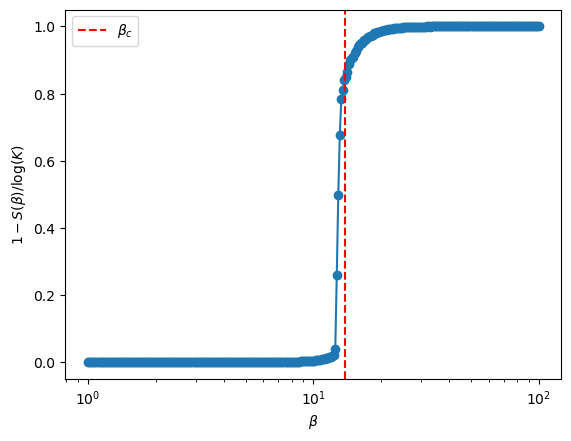

In [164]:
plt.plot(betas, 1.0-S/log(K), marker='o')
plt.axvline(beta_c, color='red', linestyle='--', label='$\\beta_c$')
if N > K:
    plt.axvline(K, color='green', linestyle='--', label='$\\beta = K$')
    plt.axvline(K/(sqrt(K/N)+1)**2, color='orange', linestyle='--', label='$\\beta \\sim K/(\\sqrt{K/N}+1)^2$')
plt.xscale('log')
plt.xlabel('$\\beta$')
plt.ylabel('$1 - S(\\beta)/\\log(K)$')
plt.legend()
plt.show()